# Object Detection & Object Tracking with OpenCV in Python

In [1]:
# libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# log version
print(f'OpenCV Version: {cv2.__version__}')

OpenCV Version: 4.13.0


# Initialize & Validate Visualization

In [2]:
# Convert OpenCV BGR to RGB and display

In [3]:
def show_image(img, title='Image Validation'):

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off') # hide axes
    plt.show()

Image loaded - Original dimension: (652, 1025, 3)


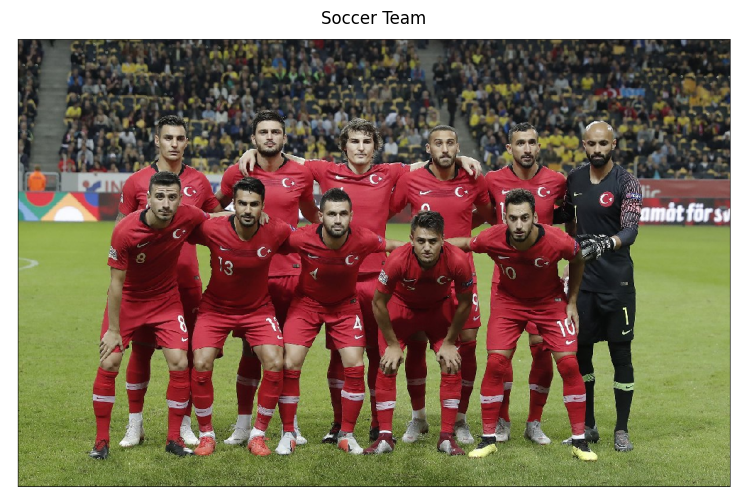

In [4]:
# ingest data
image_path = '../data/sportsteam.png'

# load image
image = cv2.imread(image_path)

print(f'Image loaded - Original dimension: {image.shape}')
show_image(image, title='Soccer Team')

# Prepare Data - Model Preprocessing

In [5]:
# Test preprocessing

In [6]:
def preprocess_for_dnn(image, target_size=(300,300), scale_factor=1.0, mean_subtraction=(104.0,177.0,123.0)):

    # binary large object / formatting
    blob = cv2.dnn.blobFromImage(
        image,
        scalefactor = scale_factor,
        size = target_size,
        mean = mean_subtraction,
        swapRB = False, # keep BGR for DNN
        crop = False
    )

    print(f'Pre-processing complete - Blob shape: {blob.shape}')
    return blob

In [7]:
# validate
image_blob = preprocess_for_dnn(image)

Pre-processing complete - Blob shape: (1, 3, 300, 300)


# Fetch Pre Trained Model & Load Deep Neural Network

In [8]:
# libraries
import urllib.request
import os

In [9]:
# urls official OpenCV ResNet-10 face detector
prototxt_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt'
caffemodel_url = 'https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel'

# local file names
prototxt_path = 'deploy.prototxt'
caffemodel_path = 'res10_300x300_ssd_iter_140000.caffemodel'

In [10]:
def download_file(url, filepath):

    # downloads if does not exist locally
    if not os.path.exists(filepath):
        print(f'Downloading {filepath}..')
        urllib.request.urlretrieve(url, filepath)
        print(f'Sucessfully downloaded {filepath}')
    else:
        print(f'{filepath} alreasy exist, skipping download..')

In [11]:
# execute downloads
download_file(prototxt_url, prototxt_path)
download_file(caffemodel_url,caffemodel_path)

deploy.prototxt alreasy exist, skipping download..
res10_300x300_ssd_iter_140000.caffemodel alreasy exist, skipping download..


In [12]:
# load model w/ OpenCV's DNN module
net = cv2.dnn.readNetFromCaffe(prototxt_path,caffemodel_path)

# pass pre precessed blob
net.setInput(image_blob)

# run validation
detections = net.forward()

print(f'Detections array shape: {detections.shape}')

Detections array shape: (1, 1, 200, 7)


# Deep Neural Network Model Evaluation - Test Images

In [13]:
# Face detection model


 Evaluating: ../data/sportsteam.png
Total faces detected above 50.0% threshold: 11


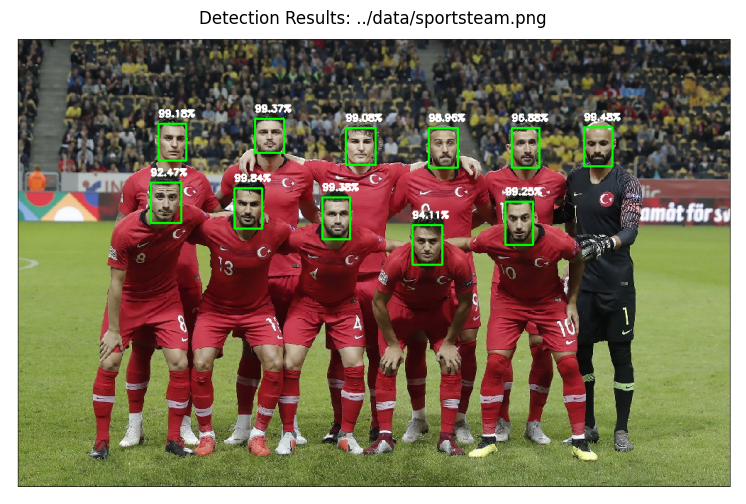


 Evaluating: ../data/family.jpg
Image normalized to: 1200x800
Total faces detected above 50.0% threshold: 5


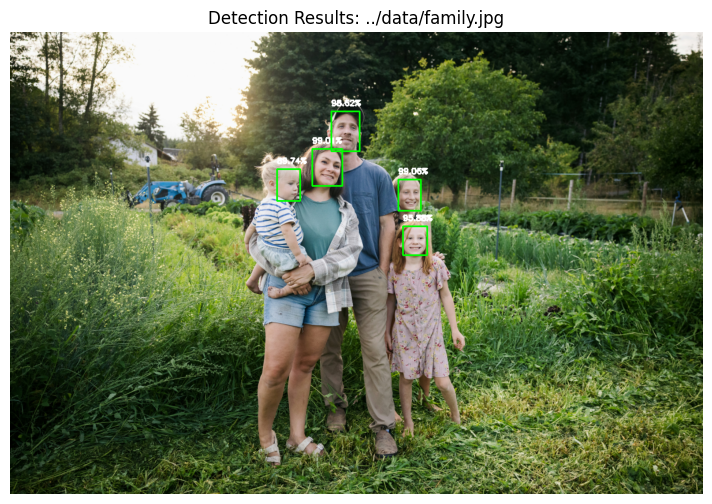


 Evaluating: ../data/edge_case.jpg
Image normalized to: 1200x804
Total faces detected above 50.0% threshold: 1


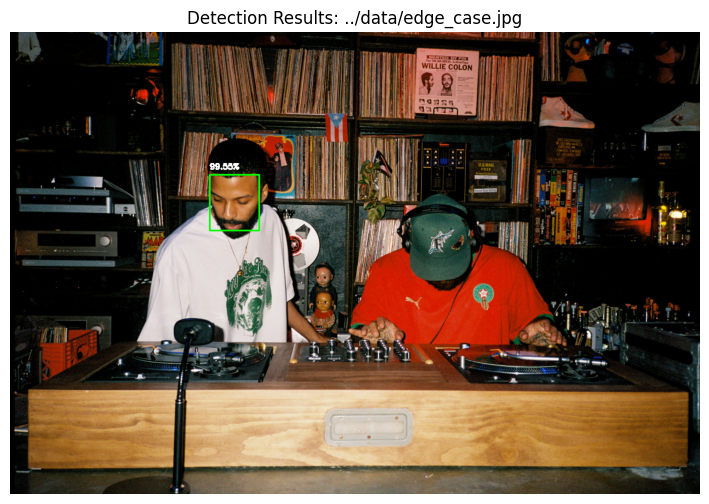

In [14]:
def evaluate_image(image_path, confidence_threshold=0.15):
    
    # Ingests an image path, pre-processes it, runs DNN validation
    print(f"\n Evaluating: {image_path}")
    
    # load  data
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load '{image_path}' - Check file name.")
        return
        
    (h, w) = image.shape[:2]

    # normalize sample images due to large scale
    max_width = 1200
    if w > max_width:
        ratio = max_width / float(w)
        new_dimensions = (max_width, int(h * ratio))
        
        # INTER_AREA shrinks images down cleanly
        image = cv2.resize(image, new_dimensions, interpolation=cv2.INTER_AREA)
        
        # update h and w to the new shrunk dimensions
        (h, w) = image.shape[:2]
        print(f"Image normalized to: {w}x{h}")
    
    output_image = image.copy()
    
    # pre-process create  Blob / resolution intially 300x300 but failed to perform
    blob = cv2.dnn.blobFromImage(image, 1.0, (600, 600), (104.0, 177.0, 123.0),crop=False)
    
    # model validate
    net.setInput(blob)
    detections = net.forward()
    
    detected_count = 0
    
    # loop over detections
    for i in range(0, detections.shape[2]):

        # extract confidence/probability for prediction
        confidence = detections[0, 0, i, 2]

        # filter weak detections
        if confidence > confidence_threshold:
            detected_count += 1
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype('int')
            
            # draw visuals
            cv2.rectangle(output_image, (startX, startY), (endX, endY), (0, 255, 0), 2)
            text = f'{confidence*100:.2f}%'
            y = startY - 10 if startY - 10 > 10 else startY + 10
            cv2.putText(output_image, text, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 2)
            
    print(f'Total faces detected above {confidence_threshold*100}% threshold: {detected_count}')
    
    # visualize output
    show_image(output_image, title=f'Detection Results: {image_path}')

# test suite
test_images = [
    '../data/sportsteam.png', 
    '../data/family.jpg', 
    '../data/edge_case.jpg'
]

for img_path in test_images:
    evaluate_image(img_path, confidence_threshold=0.50)

# Video Validation - Haar Cascade

In [15]:
# Full body tracking

In [16]:
video_path = '../data/pedestrian_video.avi'
output_path = 'haar_pedsterian_output.avi'

# OpenCV cascade folder
haar_path = os.path.join(cv2.data.haarcascades, 'haarcascade_fullbody.xml')

# initialize Haar Cascade Classifier
body_classifier = cv2.CascadeClassifier(haar_path)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f'Error, could not open at {video_path}')
else: 
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width,frame_height))

    print('Video processing..')
    frame_count = 0

    while cap.isOpened():
        ret,frame=cap.read()
        if not ret: break

        frame_count +=1

        # convert grayscale
        gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

        # detection
        bodies = body_classifier.detectMultiScale(gray,scaleFactor=1.2, minNeighbors=3)

        # boundaries
        for (x,y,w,h) in bodies:
            cv2.rectangle(frame,(x,y),(x+w,y+h), (0,255,255),2) # yellow boxes

        cv2.putText(frame, f'Haar Detections: {len(bodies)}', (20,40),cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,255,255),3)

        out.write(frame)

    cap.release()
    out.release()

    print(f'Processed {frame_count} frames')
    print(f'Check folder for output file: {output_path}')

Video processing..
Processed 795 frames
Check folder for output file: haar_pedsterian_output.avi


# Video Validation - Deep Neural Network

In [17]:
# Experiment with face detection DNN model

In [18]:
# video processing pipeline
video_path = '../data/pedestrian_video.avi'
output_path = 'DNN_output.avi'

# initialize stream
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f'Error, could not open video at {video_path} - Check file name..')
else: # get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # initialize video writer
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    print('Video processing..')

    frame_count = 0

    # loop through video by frame
    while cap.isOpened():
        ret, frame = cap.read()

        # if not frame returned
        if not ret:
            break

        frame_count += 1
        (h,w) = frame.shape[:2]

        # pre process frame
        blob = cv2.dnn.blobFromImage(
            frame,
            1.0,
            (600,600),
            (104.0,177.0,123.0)
        )

        # pass frame through network
        net.setInput(blob)
        detections = net.forward()

        # counter
        frame_face_count = 0

        # draw boxes
        for i in range(0, detections.shape[2]):
            confidence = detections[0,0,i,2]

            # 30% thresehold based on validation results
            if confidence > 0.15: 
                
                frame_face_count += 1
                
                box = detections[0,0,i,3:7] * np.array([w,h,w,h])
                (startX,startY,endX,endY) = box.astype('int')

                # clamp coords
                startX = max(0,startX)
                startY = max(0,startY)
                endX = min(w-1,endX)
                endY = min(h-1,endY)

                # draw rectangles
                cv2.rectangle(
                    frame,
                    (startX,startY),
                    (endX,endY),
                    (0,255,0),2
                )
                
        # hud counter
        hud_text = f"Faces Detected: {frame_face_count}"
        cv2.putText(frame, hud_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3) # red text, thick font
        
        # write processed frame
        out.write(frame)

    # clean release/resources
    cap.release()
    out.release()
    print(f'Processed {frame_count} frames.')
    print(f'Check folder for output file: {output_path}')

Video processing..
Processed 795 frames.
Check folder for output file: DNN_output.avi
